In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

In [6]:
df = pd.read_csv(
    '/content/drive/MyDrive/Datasets/twitter-training.csv',
    header=None,
    encoding='latin1'
)  # import the dataset

In [7]:
print(df.columns)

Index([0, 1, 2, 3], dtype='int64')


In [8]:
df.columns = ["id", "topic", "sentiment", "text"]

In [9]:
print(df.columns)

Index(['id', 'topic', 'sentiment', 'text'], dtype='object')


In [10]:
df.info()
#Dataset contains 74,682 tweets with sentiment labels.
#The target variable is 'sentiment'.
#The input feature is the tweet text stored in the 'text' column.
#There are 686 missing tweets that will need to be handled before training.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   topic      74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [11]:
df["sentiment"].value_counts()
# The dataset contains 4 sentiment classes:
# Negative, Positive, Neutral, and Irrelevant.
# Class distribution is relatively balanced, making the dataset suitable
# for training a multi-class sentiment classification model.

,count
sentiment,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990


In [12]:
#Check the missing tweets
df["text"].isnull().sum()

np.int64(686)

In [13]:
df = df.dropna(subset=["text"])

In [14]:
df.info()
# Removed rows with missing tweet text.
# Transformer models require text input, so rows with null values
# in the text column were dropped.

<class 'pandas.core.frame.DataFrame'>
Index: 73996 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         73996 non-null  int64 
 1   topic      73996 non-null  object
 2   sentiment  73996 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.8+ MB


In [15]:
df[["sentiment", "text"]].sample(5, random_state=42)

,sentiment,text
61413,Irrelevant,Looks to me like he failed to check out the wa...
44887,Irrelevant,"Wow, it takes all sorts of crazy people out th..."
73662,Neutral,Nvidia Unveils The Worldâs Fastest Gaming Mo...
36694,Neutral,Huge radio play here. Reinvention / Corporate ...
2308,Negative,SO I HAPPY WHO ABOUT THIS.


In [16]:
df["text"].duplicated().sum()

np.int64(4507)

In [18]:
df = df.drop_duplicates(subset=["text"])
# Removed duplicate tweets based on tweet text.
# This reduces the risk of the model memorizing repeated examples
# and helps produce a more reliable evaluation.

In [20]:
df.shape

(69489, 4)

In [21]:
df["sentiment"].unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

In [23]:
label_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
    "Irrelevant": 3
}

df["label"] = df["sentiment"].map(label_map)
# Convert sentiment labels into numerical values.
# Neural networks and Transformer models require numerical targets
# rather than text labels for training.

In [24]:
df[["sentiment", "label"]].head()

,sentiment,label
0,Positive,2
1,Positive,2
2,Positive,2
3,Positive,2
4,Positive,2


In [26]:
X = df["text"].astype(str).tolist()
y = df["label"].tolist()
# Separate the dataset into input texts and target labels.
# X contains the tweets, while y contains the numerical sentiment labels.

In [27]:
print(len(X))
print(len(y))
print(X[0])
print(y[0])


69489
69489
im getting on borderlands and i will murder you all ,
2


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Split the dataset into training and testing sets.
# 80% of the data will be used for training and 20% for evaluation.
# Stratification preserves the original sentiment distribution.

In [29]:
print(len(X_train))
print(len(X_test))

55591
13898


In [30]:
!pip install transformers datasets evaluate -q
# Install Hugging Face libraries needed for Transformer-based NLP modeling.
# Transformers provides pretrained models such as BERT.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
# Import Hugging Face tools for loading a pretrained tokenizer
# and a Transformer model for sentiment classification.

In [32]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
# Load the DistilBERT tokenizer.
# DistilBERT is a smaller and faster version of BERT,

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [33]:
sample_text = X_train[0]

tokens = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=128
)

tokens

# Test the tokenizer on one tweet.
# Tokenization converts raw text into numerical inputs that DistilBERT can process.

{'input_ids': [101, 2065, 2027, 2292, 2149, 17542, 1996, 5376, 1010, 2065, 2057, 2024, 6908, 2041, 1010, 1045, 2097, 5390, 4000, 1997, 6569, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [34]:
tokenizer.convert_ids_to_tokens(tokens["input_ids"][:25])

['[CLS]',
 'if',
 'they',
 'let',
 'us',
 'cancel',
 'the',
 'jump',
 ',',
 'if',
 'we',
 'are',
 'thrown',
 'out',
 ',',
 'i',
 'will',
 'cry',
 'tears',
 'of',
 'joy',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

In [36]:
train_encodings = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test,
    truncation=True,
    padding=True,
    max_length=128
)
# Tokenize all tweets in the training and test sets.
# The tokenizer converts text into numerical inputs that can be
# processed by DistilBERT. Sequences are padded and truncated
# to a maximum length of 128 tokens.

In [37]:
print(len(train_encodings["input_ids"]))
print(len(test_encodings["input_ids"]))

55591
13898


In [38]:
import torch

class TwitterSentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)
# Create a custom PyTorch Dataset.
# This organizes tokenized tweets and labels into the format
# required by Hugging Face Trainer.

In [39]:
train_dataset = TwitterSentimentDataset(train_encodings, y_train)
test_dataset = TwitterSentimentDataset(test_encodings, y_test)

print(len(train_dataset))
print(len(test_dataset))

55591
13898


At this point we have:

✅ Cleaned data
✅ Encoded labels
✅ Split train/test
✅ Loaded DistilBERT tokenizer
✅ Tokenized all tweets
✅ Created PyTorch datasets

Now we're about to load the actual Transformer model.

In [40]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)
# Load a pretrained DistilBERT model for sequence classification.
# The model already understands language and will be fine-tuned
# to predict the 4 sentiment classes in our dataset.

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [41]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    predictions = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }
# Define evaluation metrics for the sentiment classifier.
# Accuracy measures overall correctness, while precision, recall,
# and F1-score give a more complete view of model performance.

In [43]:
from transformers import TrainingArguments
# Import TrainingArguments to define the training configuration
# for fine-tuning the DistilBERT model.

In [44]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True
)
# Define training settings for fine-tuning DistilBERT.
# The model will train for 2 epochs, evaluate after each epoch,
# and save the best-performing model.

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [46]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
# Create the Hugging Face Trainer.
# The Trainer combines the model, training settings, datasets,
# and evaluation metrics into one training pipeline.

In [48]:
#TRAIN THE MODEL
trainer.train()
# Fine-tune the DistilBERT model on the Twitter sentiment dataset.
# During training, the model learns to classify tweets into
# Negative, Neutral, Positive, or Irrelevant categories.

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.478119,0.439878,0.847820,0.847026,0.848258,0.847820
2,0.197311,0.331077,0.905670,0.905639,0.905680,0.905670


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6950, training_loss=0.4919516614186678, metrics={'train_runtime': 1373.2336, 'train_samples_per_second': 80.964, 'train_steps_per_second': 5.061, 'total_flos': 3682128905742336.0, 'train_loss': 0.4919516614186678, 'epoch': 2.0})

# The DistilBERT model achieved strong performance after 2 epochs.
# Validation accuracy improved from 84.78% in epoch 1 to 90.57% in epoch 2.
# The final F1-score was 90.56%, showing that the model performs well
# across the four sentiment classes.

In [49]:
eval_results = trainer.evaluate()

eval_results

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.197311,0.331077,2,0.905670,0.905639,0.905680,0.905670


{'eval_loss': 0.3310765326023102,
 'eval_accuracy': 0.9056698805583537,
 'eval_f1': 0.9056392360771967,
 'eval_precision': 0.9056804802526751,
 'eval_recall': 0.9056698805583537}

# Final Evaluation
#
# The fine-tuned DistilBERT model achieved:
# Accuracy  : 90.57%
# F1 Score  : 90.56%
# Precision : 90.57%
# Recall    : 90.57%
#
# These results indicate excellent performance on the Twitter
# sentiment classification task. The Transformer-based approach
# significantly benefits from contextual understanding of language,
# allowing it to outperform many traditional NLP methods.

In [50]:
predictions = trainer.predict(test_dataset)
# Generate predictions on the test dataset.
# These predictions will be used to create a confusion matrix
# and a detailed classification report.

In [51]:
import numpy as np

y_pred = np.argmax(predictions.predictions, axis=1)

In [52]:
print(y_pred[:10])
# Convert prediction probabilities into class labels.
# Argmax selects the class with the highest predicted probability.

[0 3 0 0 3 2 3 3 1 3]


In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm
# Compute the confusion matrix.
# The confusion matrix shows how often each sentiment class
# is correctly classified and where the model makes mistakes.

array([[3893,  126,  142,   73],
       [ 115, 3093,  120,   80],
       [ 135,  133, 3459,   86],
       [  86,   90,  125, 2142]])

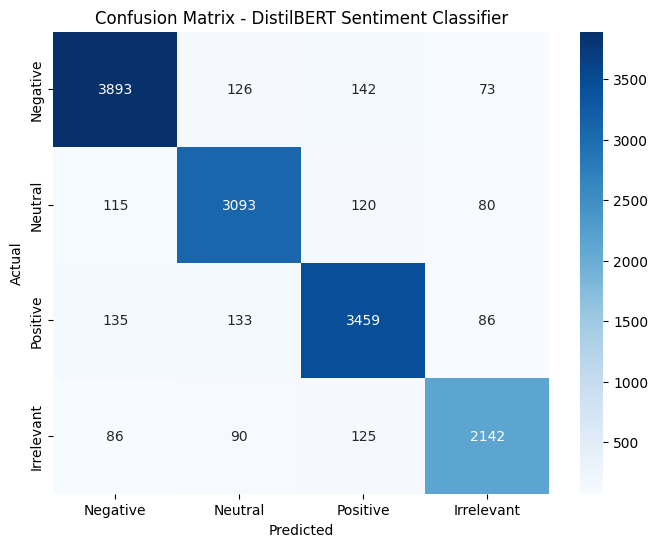

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Neutral","Positive","Irrelevant"],
    yticklabels=["Negative","Neutral","Positive","Irrelevant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT Sentiment Classifier")
plt.show()
# Visualize the confusion matrix as a heatmap.
# Values along the diagonal represent correct predictions,
# while off-diagonal values represent classification errors.

# Confusion Matrix Analysis
#
# The majority of predictions lie along the diagonal,
# indicating strong classification performance across all classes.
#
# The most common errors occur between Positive and Negative
# sentiments and between Positive and Neutral sentiments,
# which is expected due to overlapping language patterns.
#
# The Irrelevant class is identified particularly well,
# with relatively few misclassifications.
#
# Overall, the confusion matrix confirms that the fine-tuned
# DistilBERT model performs consistently across all four classes.

In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive",
            "Irrelevant"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92      4234
     Neutral       0.90      0.91      0.90      3408
    Positive       0.90      0.91      0.90      3813
  Irrelevant       0.90      0.88      0.89      2443

    accuracy                           0.91     13898
   macro avg       0.90      0.90      0.90     13898
weighted avg       0.91      0.91      0.91     13898



# Classification Report Analysis
#
# The fine-tuned DistilBERT model achieved strong performance across
# all sentiment classes, with F1-scores ranging from 0.89 to 0.92.
#
# Negative sentiment achieved the highest performance (F1 = 0.92),
# while the Irrelevant class was the most challenging (F1 = 0.89).
#
# The overall weighted F1-score of 0.91 indicates that the model
# generalizes well across all four sentiment categories.
#
# Combined with the confusion matrix, the results demonstrate that
# DistilBERT effectively captures contextual information and provides
# highly accurate sentiment classification on Twitter data.

In [56]:
save_path = "/content/drive/MyDrive/Models/Twitter_Sentiment_DistilBERT"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
# Save the fine-tuned DistilBERT model and tokenizer to Google Drive.
# Saving both components allows the model to be reloaded later
# for inference, deployment, or further training.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Models/Twitter_Sentiment_DistilBERT/tokenizer_config.json',
 '/content/drive/MyDrive/Models/Twitter_Sentiment_DistilBERT/tokenizer.json')

In [57]:
import os

os.listdir("/content/drive/MyDrive/Models/Twitter_Sentiment_DistilBERT")

['config.json',
 'model.safetensors',
 'training_args.bin',
 'tokenizer_config.json',
 'tokenizer.json']

In [59]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/Models/Twitter_Sentiment_DistilBERT"

loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)

loaded_model = AutoModelForSequenceClassification.from_pretrained(model_path)
# Reload the saved DistilBERT model and tokenizer from Google Drive.
# This verifies that the saved model can be reused for inference
# without retraining.

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [60]:
#Test the saved model on a custom tweet
import torch

text = "I love this game, it is amazing!"

inputs = loaded_tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = loaded_model(**inputs)

predicted_class = torch.argmax(outputs.logits, dim=1).item()

predicted_class
# Test the saved model on a custom tweet.
# The tokenizer prepares the text, and the model predicts
# the most likely sentiment class.

2

In [61]:
id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive",
    3: "Irrelevant"
}

In [62]:
print(id2label[predicted_class])
# Convert the predicted numerical class back into
# a human-readable sentiment label.

Positive


In [63]:
def predict_sentiment(text):
    inputs = loaded_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = loaded_model(**inputs)

    predicted_class = torch.argmax(outputs.logits, dim=1).item()

    return id2label[predicted_class]
    # Create a reusable prediction function.
# This function takes a new tweet as input and returns
# the predicted sentiment label from the trained model.

In [64]:
predict_sentiment("This game is terrible and I hate it")

'Negative'

In [65]:
test_tweets = [
    "I absolutely love this game. Best purchase ever!",
    "This update ruined everything.",
    "The game was released yesterday.",
    "Nvidia announced a new graphics card.",
    "The customer service was fantastic.",
    "I want my money back.",
    "The graphics are okay, nothing special.",
    "This is the worst experience I have ever had."
]

for tweet in test_tweets:
    print(f"Tweet: {tweet}")
    print(f"Prediction: {predict_sentiment(tweet)}")
    print("-" * 50)
# Test the fine-tuned DistilBERT model on multiple custom tweets.
# This helps validate that the model generalizes to unseen text
# and produces sensible sentiment predictions.

Tweet: I absolutely love this game. Best purchase ever!
Prediction: Positive
--------------------------------------------------
Tweet: This update ruined everything.
Prediction: Negative
--------------------------------------------------
Tweet: The game was released yesterday.
Prediction: Positive
--------------------------------------------------
Tweet: Nvidia announced a new graphics card.
Prediction: Neutral
--------------------------------------------------
Tweet: The customer service was fantastic.
Prediction: Positive
--------------------------------------------------
Tweet: I want my money back.
Prediction: Negative
--------------------------------------------------
Tweet: The graphics are okay, nothing special.
Prediction: Positive
--------------------------------------------------
Tweet: This is the worst experience I have ever had.
Prediction: Negative
--------------------------------------------------


# Custom inference testing demonstrated that the model generalizes
# well to unseen examples. Strong positive and negative statements
# were classified correctly, while some neutral statements were
# occasionally predicted as positive.
#
# These errors are expected because neutral and mildly positive
# language often share similar vocabulary and context.
#
# Overall, the model shows strong practical performance and
# meaningful sentiment understanding beyond the training data.